In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import awkward as ak

import sys
import os
import json
import glob
import time
import importlib
import coffea.util as util

# Remove the bad cached import
for mod in ["analysisTools", "analysisSubroutines", "routines"]:
    if mod in sys.modules:
        del sys.modules[mod]

# Use the analysisTools directory inside the current notebook directory
analysis_tools_path = os.path.abspath("./analysisTools")
print("Using analysisTools path:", analysis_tools_path)

# Put it first
sys.path.insert(0, analysis_tools_path)

from analysisTools import Analyzer
from analysisTools import loadSchema
import analysisTools as tools
import analysisSubroutines as routines

print("analysisTools loaded from:", tools.__file__)
print("Has Analyzer?", hasattr(tools, "Analyzer"))
print("Has muonRecoProcessor?", hasattr(tools, "muonRecoProcessor"))

Using analysisTools path: /uscms_data/d3/abdelham/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools
analysisTools loaded from: /uscms_data/d3/abdelham/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools/analysisTools.py
Has Analyzer? True
Has muonRecoProcessor? True


In [15]:
!ls -lh analysisTools/
!grep -n "class Analyzer" analysisTools/analysisTools.py
!grep -n "muonRecoProcessor" analysisTools/analysisTools.py

total 216K
drwxr-xr-x  2 abdelham us_cms 169 May 19 16:19 __pycache__
-rw-r--r--  1 abdelham us_cms 525 May 12 13:53 analysisImports.py
-rw-r--r--  1 abdelham us_cms 58K May 12 13:53 analysisSubroutines.py
-rw-r--r--  1 abdelham us_cms 48K May 19 16:07 analysisTools.py
-rw-r--r--  1 abdelham us_cms 15K May 12 13:53 analysisTools_old.py
drwxr-xr-x 11 abdelham us_cms 167 May 12 13:53 corrections
-rw-r--r--  1 abdelham us_cms 19K May 12 13:53 corrections.py
-rw-r--r--  1 abdelham us_cms 12K May 12 13:53 mySchema.py
-rw-r--r--  1 abdelham us_cms 13K May 12 13:53 mySchema_newCoffea.py
-rw-r--r--  1 abdelham us_cms 12K May 12 13:53 plotTools.py
-rw-r--r--  1 abdelham us_cms 15K May 12 13:53 skimmerTools.py
-rw-r--r--  1 abdelham us_cms 12K May 12 13:53 utils.py
46:class Analyzer:
173:            proc = muonRecoProcessor(self.sample_names,self.sample_info,self.sample_locs,mode=self.mode,**kwargs)
742:class muonRecoProcessor(processor.ProcessorABC):


In [4]:
ana = Analyzer(
    fileList="configs/sample_configs/signal_2022EE_iDMmu_aEM.json",
    histoList="dummy.py",
    cuts="dummyCuts.py",
    max_samples=1,
    max_files_per_samp=2,
)

out = ana.process(
    treename="ntuples/outT",
    execr="futures",
    workers=4,
    procType="muonReco",
    gen_pt_min=3.0,
    gen_eta_max=2.4,
    reco_pt_min=0.0,
    dr_max=0.1,
    require_dsa_id=False,
)

util.save(out, "test_iDMmu_2022EE_muRecoEff.coffea")

Output()

Output()

In [18]:
from pathlib import Path

p = Path("analysisTools/analysisTools.py")
txt = p.read_text()

txt = txt.replace("sample['blacklist']", "sample.get('blacklist', [])")

p.write_text(txt)

print("Patched analysisTools.py")

Patched analysisTools.py


In [19]:
import json

json_path = "configs/sample_configs/signal_2022EE_iDMmu_aEM.json"

with open(json_path, "r") as f:
    samples = json.load(f)

for s in samples:
    s.setdefault("blacklist", [])

with open(json_path, "w") as f:
    json.dump(samples, f, indent=4)

print(f"Updated {json_path}")

Updated configs/sample_configs/signal_2022EE_iDMmu_aEM.json


In [26]:
t0 = time.time()

out = ana.process(
    treename="ntuples/outT",
    execr="futures",
    workers=4,
    procType="muonReco",
    gen_pt_min=3.0,
    gen_eta_max=2.4,
    reco_pt_min=0.0,
    dr_max=0.1,
    require_dsa_id=False,
)

dt = time.time() - t0

# savemetrics=True may return (histos, metrics)
if isinstance(out, tuple):
    histos = out[0]
    metrics = out[1]
else:
    histos = out
    metrics = None

counts_h = histos["muon_reco_counts"]

axis_names = [ax.name for ax in counts_h.axes]
samp_axis = "samp" if "samp" in axis_names else "sample"
quantity_axis = "quantity"

samples = list(counts_h.axes[samp_axis])
quantities = list(counts_h.axes[quantity_axis])

total_events = 0.0
total_gen_muons = 0.0
total_prompt = 0.0
total_dsa = 0.0
total_either = 0.0

print("=" * 80)
print("Muon reco efficiency Coffea job finished")
print("=" * 80)

for samp in samples:
    vals = {}

    print(f"\nSample: {samp}")

    for q in quantities:
        val = counts_h[{samp_axis: samp, quantity_axis: q}].value
        vals[q] = float(val)
        print(f"  {q:30s} {float(val):.0f}")

    total_events += vals.get("n_events", 0.0)
    total_gen_muons += vals.get("n_gen_mu", vals.get("n_gen_mu_den", 0.0))
    total_prompt += vals.get("n_prompt_matched", 0.0)
    total_dsa += vals.get("n_dsa_matched", 0.0)
    total_either += vals.get("n_either_matched", 0.0)

    den = vals.get("n_gen_mu", vals.get("n_gen_mu_den", 0.0))

    if den > 0:
        print("  --- efficiencies ---")
        print(f"  prompt_eff{'':18s} {vals.get('n_prompt_matched', 0.0) / den:.6f}")
        print(f"  dsa_eff{'':21s} {vals.get('n_dsa_matched', 0.0) / den:.6f}")
        print(f"  either_eff{'':18s} {vals.get('n_either_matched', 0.0) / den:.6f}")

print("\n" + "=" * 80)
print("Total summary")
print("=" * 80)
print(f"Processed events:        {int(total_events)}")
print(f"Denominator gen muons:   {int(total_gen_muons)}")
print(f"Prompt matched muons:    {int(total_prompt)}")
print(f"DSA matched muons:       {int(total_dsa)}")
print(f"Either matched muons:    {int(total_either)}")
print(f"Time taken:              {dt:.2f} s = {dt/60:.2f} min")

if total_gen_muons > 0:
    print(f"Prompt efficiency:       {total_prompt / total_gen_muons:.6f}")
    print(f"DSA efficiency:          {total_dsa / total_gen_muons:.6f}")
    print(f"Either efficiency:       {total_either / total_gen_muons:.6f}")

print("=" * 80)

util.save(histos, "test_iDMmu_2022EE_muRecoEff.coffea")

Output()

Muon reco efficiency Coffea job finished

Sample: sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1
  n_events                       10000
  n_events_ge2_gen_mu            1455
  n_gen_mu_den                   5581
  n_prompt_matched               5159
  n_dsa_matched                  3157
  n_either_matched               5200
  n_events_both_prompt           1335
  n_events_both_dsa              773
  n_events_both_either           1353
  --- efficiencies ---
  prompt_eff                   0.924386
  dsa_eff                      0.565669
  either_eff                   0.931733

Total summary
Processed events:        10000
Denominator gen muons:   5581
Prompt matched muons:    5159
DSA matched muons:       3157
Either matched muons:    5200
Time taken:              1.91 s = 0.03 min
Prompt efficiency:       0.924386
DSA efficiency:          0.565669
Either efficiency:       0.931733


In [2]:
import sys

for mod in ["analysisTools"]:
    if mod in sys.modules:
        del sys.modules[mod]

from analysisTools import Analyzer
import analysisTools as tools

print("analysisTools loaded from:", tools.__file__)
print("Has muonRecoProcessor?", hasattr(tools, "muonRecoProcessor"))

analysisTools loaded from: /uscms_data/d3/abdelham/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools/analysisTools.py
Has muonRecoProcessor? True


In [5]:
t0 = time.time()

out = ana.process(
    treename="ntuples/outT",
    execr="futures",
    workers=4,
    procType="muonReco",
    gen_pt_min=3.0,
    gen_eta_max=2.4,
    reco_pt_min=0.0,
    dr_max=0.1,
    require_dsa_id=False,
)

dt = time.time() - t0

if isinstance(out, tuple):
    histos = out[0]
    metrics = out[1]
else:
    histos = out
    metrics = None

print(f"Done in {dt:.2f} s = {dt/60:.2f} min")

Output()

Done in 1.62 s = 0.03 min


In [6]:
counts_h = histos["muon_reco_counts"]

axis_names = [ax.name for ax in counts_h.axes]
samp_axis = "samp" if "samp" in axis_names else "sample"

for samp in counts_h.axes[samp_axis]:
    n_dsa = counts_h[{samp_axis: samp, "quantity": "n_dsa_reco_muons"}].value
    n_dsa_pass = counts_h[{samp_axis: samp, "quantity": "n_dsa_reco_muons_pass_id"}].value
    n_evt_dsa = counts_h[{samp_axis: samp, "quantity": "n_events_with_dsa"}].value
    n_evt_dsa_pass = counts_h[{samp_axis: samp, "quantity": "n_events_with_dsa_pass_id"}].value

    print("=" * 80)
    print(samp)
    print(f"DSA reco muons total:              {n_dsa:.0f}")
    print(f"DSA reco muons passing ID:         {n_dsa_pass:.0f}")
    print(f"Events with >=1 DSA muon:          {n_evt_dsa:.0f}")
    print(f"Events with >=1 DSA muon pass ID:  {n_evt_dsa_pass:.0f}")

    if n_dsa > 0:
        print(f"Object-level DSA ID pass fraction: {n_dsa_pass / n_dsa:.6f}")

    if n_evt_dsa > 0:
        print(f"Event-level DSA ID pass fraction:  {n_evt_dsa_pass / n_evt_dsa:.6f}")

sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1
DSA reco muons total:              14027
DSA reco muons passing ID:         7883
Events with >=1 DSA muon:          7440
Events with >=1 DSA muon pass ID:  5342
Object-level DSA ID pass fraction: 0.561988
Event-level DSA ID pass fraction:  0.718011


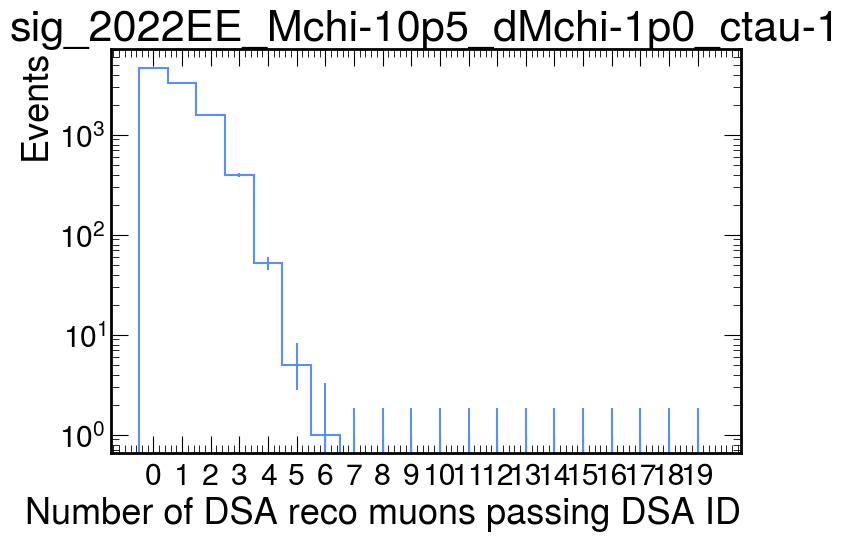

In [7]:
import mplhep as hep
hep.style.use("CMS")

h = histos["n_dsa_muons_pass_id"]

samp_axis = "samp" if "samp" in [ax.name for ax in h.axes] else "sample"
samples = list(h.axes[samp_axis])

samp = samples[0]

plt.figure(figsize=(8, 6))
hep.histplot(
    h[{samp_axis: samp}],
    yerr=True,
)
plt.yscale("log")
plt.xlabel("Number of DSA reco muons passing DSA ID")
plt.ylabel("Events")
plt.title(samp)
plt.tight_layout()
plt.show()

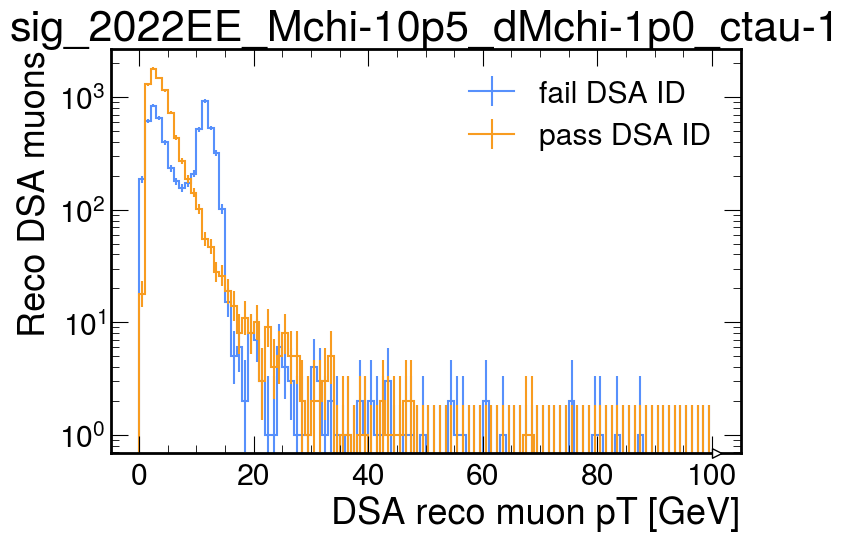

In [8]:
h = histos["dsa_muon_pt_pass_id"]

samp_axis = "samp" if "samp" in [ax.name for ax in h.axes] else "sample"
samp = list(h.axes[samp_axis])[0]

plt.figure(figsize=(8, 6))

hep.histplot(
    [
        h[{samp_axis: samp, "pass_id": 0}],
        h[{samp_axis: samp, "pass_id": 1}],
    ],
    label=["fail DSA ID", "pass DSA ID"],
    yerr=True,
)

plt.yscale("log")
plt.xlabel("DSA reco muon pT [GeV]")
plt.ylabel("Reco DSA muons")
plt.title(samp)
plt.legend()
plt.tight_layout()
plt.show()

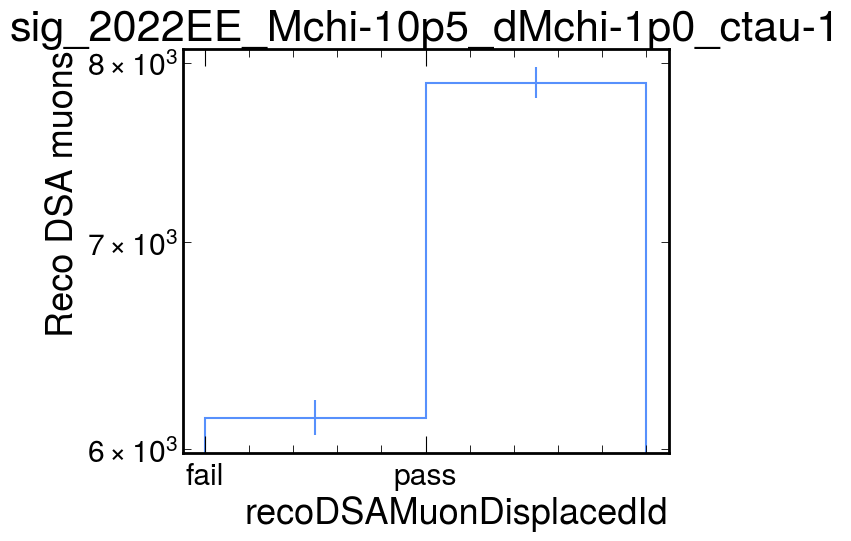

In [9]:
h = histos["dsa_muon_pass_id"]

samp_axis = "samp" if "samp" in [ax.name for ax in h.axes] else "sample"
samp = list(h.axes[samp_axis])[0]

plt.figure(figsize=(7, 6))
hep.histplot(
    h[{samp_axis: samp}],
    yerr=True,
)
plt.yscale("log")
plt.xlabel("recoDSAMuonDisplacedId")
plt.ylabel("Reco DSA muons")
plt.xticks([0, 1], ["fail", "pass"])
plt.title(samp)
plt.tight_layout()
plt.show()